## Ensemble Learning

## Prepare data for ensemble learning:

In [14]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.3)            # X = (x1, x2)，y=0 or 1 (category)

from sklearn.model_selection import train_test_split                               
X_train, X_test, y_train, y_test = train_test_split(    # train test split
    X, y,
    test_size=0.2,
    random_state=42
)

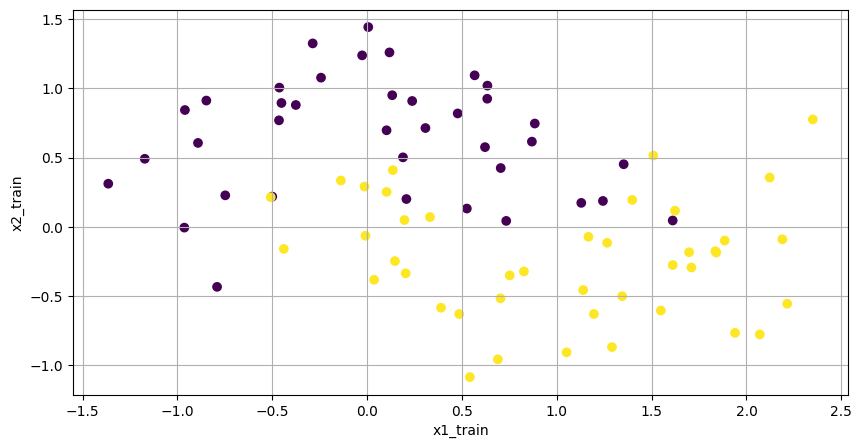

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train)
plt.xlabel('x1_train')
plt.ylabel('x2_train')
plt.grid(True)
plt.show()

# to restart kernel: cmd+shift+P, type in restart kernel

## Voting Classifier:

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

from sklearn.ensemble import VotingClassifier           # 定义voting classifer，集合了randomforest, logistic regression, svc
voting_clf = VotingClassifier(
    estimators = [
        ('lr', log_clf),
        ('rf', rnd_clf),
        ('svc', svm_clf)
    ],
    voting = 'hard'
)

voting_clf.fit(X_train, y_train)                        # 训练voting classifier

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score

d = []
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    d.append({"Model": clf.__class__.__name__, "Accuracy": acc})

df = pd.DataFrame(d)
df = df.sort_values(by="Accuracy", ascending=False)
df

,Model,Accuracy
1,RandomForestClassifier,0.95
2,SVC,0.95
3,VotingClassifier,0.95
0,LogisticRegression,0.75


## Bagging and Pasting:
Train multiple predictors using the same algorithm, but different training data.
The data used to train each predictor is a randomly selected subset of the training data. The selection process is either bagging (with replacement) or pasting (without replacement).

The BaggingClassifier automatically performs soft voting instead of hard voting if the base classifier can estimate class probabilities (i.e., if it has a predict_proba()method).

Below is an example of applying bagging method.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),                       # select a base model (type of predictor to use)
    n_estimators=500,                               # set total # of predictors in this ensemble
    max_samples=100,                                # max number of instances in a random subset used to train a single predictor
    bootstrap=True,                                 # True means using bagging method to select training subset
    n_jobs=-1                                       # set number of CPU cores to train. -1 means using all CPU cores
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

Out-of-bag (OOB) evaluation is an useful method for evaluating the performance of a trained ensemble without the need for creating a separate validation set.

Steps: (suppose there are m instances in the training data)
Randomly select m times with replacement to form a training set for each predictor. Train the predictors.

By math, each predictor learns from 63% of the data and never sees 37% of the data.

For each instance, select its OOB predictors(trees), average their outputs(probabilities). Get a result/predicted class and compare it with instance i's label.

Set count=0. If instance i's predicted result=label, add one to count.

When the process is repeated for each instance in the training data, calculate count/m, where m is the total number of instances of the training data. 

This is the OOB accuracy of this trained ensemble. It can reflects an expected performance of the ensemble on the test set.


In [ ]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), 
    n_estimators=500,
    bootstrap=True,                 # select instances with replacement to form subsets
    n_jobs=-1, 
    oob_score=True                  # 使用OOB evaluation
)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_                  # 输出OOB accuracy，估测模型泛化能力

from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)      # 输出ensemble在test set上的accuracy/performance

## Random Forest:
Is a resemble of many decisioin trees. For each tree, randomly select a subset of training instances with replacement (bootstrap sampling = True). At each node, randomly select a subset of training features, and find the best split in this group of selected features. Move on to child nodes and repeat the same steps until max leaf node or purity or max depth is met. 
Follow the same steps for every tree model. The trained ensemble is a random forest. 

For predictor, it works the same as other ensemble learning models. Can do classification (majority vote) and regression (take the mean of every output) jobs.

Random forests can lower the correlation between trees, which reflects the core notion of "wisdom of the crowds". In other words, a crowd's aggregate decision/knowledge is often better than a decision made by an expert.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(                                   # 训练一个random forest using RandomForestClassifier()
    n_estimators=500,                                               # RandomForestClassifier会自动用bootstrap方法给每棵树随机选择training subset。对于每个node也会自动随机选择feature subset做best split。
    max_leaf_nodes=16,                                              # 对于RandomForestClassifier()，classification的话每个node选择sqrt(p)个feature，regression的话选择p/3个feature
    n_jobs=-1,
    oob_score = True                                                # oob_score是内置的，训练好之后可以直接调取：rnd_clf.oob_score_
)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
rnd_clf.oob_score_
rnd_clf.feature_importance_                                         # 输出feature importance，看哪些feature对于决策更加重要, which helps for feature selection

bag_clf = BaggingClassifier(                                        # 用BaggingClassifier()实现同样的功能。每棵树训练用的样本数量=训练集数量，但样本是bootstrap随机抽取的(with replacement)。
    DecisionTreeClassifier(splitter="random", max_leaf_nodes=16),
    n_estimators=500, 
    max_samples=1.0, 
    bootstrap=True, 
    n_jobs=-1
)

## AdaBoost:
main difference with random forest: Models in adaboost are trained sequentially, so they are not independent. Each later model aims to correct erros made by its predecessor.
Specific algorithm of training AdaBoost can be found on paper notes.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(                               
    DecisionTreeClassifier(max_depth=1),                        # 故意设定非常简单的树(weak learner, depth = 1)
    n_estimators=200,
    algorithm="SAMME.R",
    learning_rate=0.5
)
ada_clf.fit(X_train, y_train)

## Gradient Boosting:
gradient boosting is also a type of ensemble learning model, and each predictor in the ensemble is trained sequentially.
Each tree after the first one is intended to model the residual errors.
Suppose the first model is h1, and the ensemble has a total of n models.
Then the final model is h(x) = h1(x) + $\eta$ h2(x)....+ $\eta$ hn(x), where $\eta$ is the learning rate.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbrt = GradientBoostingRegressor(
    max_depth=2,                                                # 每棵树都很浅
    n_estimators=3,                                             # ensemble一共有三棵树，按顺序训练
    learning_rate=1.0
)
gbrt.fit(X, y)


# use early stopping to find the optimal number of trees:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y)

gbrt = GradientBoostingRegressor(                               # 先训练一个有120个predictor的大模型，learning rate不设定的话默认0.1
    max_depth=2, 
    n_estimators=120
)
gbrt.fit(X_train, y_train)

errors = [                                                      # staged_predict允许用大模型里的单个predictor一个一个进行预测。input X_val, get y_pred, compute MSE using y_pred and y_val
    mean_squared_error(y_val, y_pred)                           # errors是一个list，记录了用一个模型，两个模型...120个模型预测的error。
    for y_pred in gbrt.staged_predict(X_val)
]
bst_n_estimators = np.argmin(errors) + 1                        # best number of estimators: error list中最小的error对应的位置+1，因为位置计数是从0开始

gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=bst_n_estimators
)
gbrt_best.fit(X_train, y_train)


# another way of implementing early stopping: stop when the next 5 iterations cannot lower MSE, which can be more time efficient
gbrt = GradientBoostingRegressor(
    max_depth=2, 
    warm_start=True
)
min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            break # early stopping

## XGB: 
is faster and scales well. 

In [ ]:
import xgboost                              # 注意需要重新设置环境，导入xgboost才不会报错
xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],              # 告诉模型每一轮都在验证集上评估效果
    early_stopping_rounds=3                 # 停止，如果连续3轮的表现都没有提升
)
y_pred = xgb_reg.predict(X_val)